In [1]:
# Verificar GPU en Colab
import tensorflow as tf
print("GPU disponible:", tf.config.list_physical_devices('GPU'))
# Imports
import numpy as np
import keras
from keras import layers
# Descargar dataset
!gdown 199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN -O titulares.txt
# Cargar texto
with open('titulares.txt', 'r', encoding='utf-8') as f:
    text = f.read().lower() # Convert text to lowercase
    print(f"Caracteres totales: {len(text)}")
    print(f"Muestra:\n{text[:500]}")

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Downloading...
From: https://drive.google.com/uc?id=199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN
To: /content/titulares.txt
100% 60.4k/60.4k [00:00<00:00, 109MB/s]
Caracteres totales: 60438
Muestra:
nueva ley de energia promete revolucionar el sector electrico
el cambio climatico sigue siendo una amenaza global
inversionistas buscan oportunidades en energias renovables
aumenta la demanda de vehiculos electricos
vacunas contra covid19 cuando estaremos todos protegidos
el debate sobre las vacunas sigue dividiendo opiniones
expertos en salud analizan la efectividad de las vacunas
vacunacion masiva contra el coronavirus en marcha
el mercado de criptomonedas se dispara a nuevas alturas
es bitcoi


In [2]:
# Crear vocabulario
vocab = sorted(set(text))
vocab_size = len(vocab)
print(f"Vocabulario: {vocab_size} caracteres únicos")
# Mapeos
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for i, ch in enumerate(vocab)}
def encode(s):
 return [char_to_idx[c] for c in s]
def decode(ids):
  return ''.join([idx_to_char[i] for i in ids])
# Test
encoded_hola = encode("hola")
print(encoded_hola)
print(decode([15,22,19,8]))

Vocabulario: 33 caracteres únicos
[15, 22, 19, 8]
hola


In [3]:
# Parámetros
SEQ_LENGTH = 80
BATCH_SIZE = 64
# Tokenizar todo
tokens = np.array(encode(text))
# Crear secuencias X, y
def crear_secuencias(tokens, seq_len):
  X, y = [], []
  for i in range(len(tokens) - seq_len):
    X.append(tokens[i:i+seq_len])
    y.append(tokens[i+1:i+seq_len+1])
  return np.array(X), np.array(y)
X, y = crear_secuencias(tokens, SEQ_LENGTH)
print(f"Secuencias: {X.shape}")
# Dataset de TensorFlow
dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Secuencias: (60358, 80)


In [4]:
class TokenAndPositionEmbedding(layers.Layer):
  def __init__(self, maxlen, vocab_size, embed_dim):
    super().__init__()
    self.token_emb = layers.Embedding(input_dim=vocab_size,
                                     output_dim=embed_dim)
    self.pos_emb = layers.Embedding(input_dim=maxlen,
                                   output_dim=embed_dim)

  def call(self, x):
    maxlen = tf.shape(x)[-1]
    positions = tf.range(start=0, limit=maxlen, delta=1)
    positions = self.pos_emb(positions)
    x = self.token_emb(x)
    return x + positions

In [5]:
class TransformerBlock(layers.Layer):
  def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
    super().__init__()
    self.att = layers.MultiHeadAttention(num_heads=num_heads,
                                         key_dim=embed_dim)
    self.ffn = keras.Sequential([
        layers.Dense(ff_dim, activation="gelu"),
        layers.Dense(embed_dim),
    ])
    self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
    self.dropout1 = layers.Dropout(dropout)
    self.dropout2 = layers.Dropout(dropout)

  def causal_attention_mask(self, batch_size, seq_len):
    """Máscara para que cada posición solo vea anteriores."""
    i = tf.range(seq_len)[:, tf.newaxis]
    j = tf.range(seq_len)
    mask = tf.cast(i >= j, dtype=tf.float32)
    mask = tf.reshape(mask, [1, 1, seq_len, seq_len])
    return tf.tile(mask, [batch_size, 1, 1, 1])

  def call(self, inputs, training=None): # Changed to make training optional
    batch_size = tf.shape(inputs)[0]
    seq_len = tf.shape(inputs)[1]
    mask = self.causal_attention_mask(batch_size, seq_len)
    attn_output = self.att(inputs, inputs, attention_mask=mask)
    attn_output = self.dropout1(attn_output, training=training)
    out1 = self.layernorm1(inputs + attn_output)
    ffn_output = self.ffn(out1)
    ffn_output = self.dropout2(ffn_output, training=training)
    return self.layernorm2(out1 + ffn_output)

In [6]:
EMBED_DIM = 256
NUM_HEADS = 4
FF_DIM = 512
NUM_BLOCKS = 4

def crear_modelo():
  inputs = layers.Input(shape=(SEQ_LENGTH,), dtype=tf.int32)
  x = TokenAndPositionEmbedding(SEQ_LENGTH, vocab_size, EMBED_DIM)(inputs)
  for _ in range(NUM_BLOCKS):
    x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
  outputs = layers.Dense(vocab_size, activation="softmax")(x)
  return keras.Model(inputs=inputs, outputs=outputs)

model = crear_modelo()
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 80, 256)        │        28,928 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 80, 33)         │         8,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,300,769 (20.22 MB)

 Trainable params: 5,300,769 (20.22 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
optimizer=keras.optimizers.Adam(learning_rate=1e-3),
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)
callbacks = [
keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]
history = model.fit(dataset, epochs=30, callbacks=callbacks)

Epoch 1/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 109s 93ms/step - accuracy: 0.7106 - loss: 0.9172 - learning_rate: 0.0010
Epoch 2/30
  1/944 ━━━━━━━━━━━━━━━━━━━━ 1:59 127ms/step - accuracy: 0.6518 - loss: 1.4387

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.8969 - loss: 0.3206 - learning_rate: 0.0010
Epoch 3/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9269 - loss: 0.2242 - learning_rate: 0.0010
Epoch 4/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9354 - loss: 0.1968 - learning_rate: 0.0010
Epoch 5/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9402 - loss: 0.1812 - learning_rate: 0.0010
Epoch 6/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9428 - loss: 0.1723 - learning_rate: 0.0010
Epoch 7/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9449 - loss: 0.1651 - learning_rate: 0.0010
Epoch 8/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9467 - loss: 0.1592 - learning_rate: 0.0010
Epoch 9/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9480 - loss: 0.1549 - learning_rate: 0.0010
Epoch 10/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9488 - loss: 0.1522 - learning_rate: 0.0010
Ep

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9521 - loss: 0.1412 - learning_rate: 0.0010
Epoch 15/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9525 - loss: 0.1394 - learning_rate: 0.0010
Epoch 16/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9528 - loss: 0.1383 - learning_rate: 0.0010
Epoch 17/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9535 - loss: 0.1363 - learning_rate: 0.0010
Epoch 18/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9536 - loss: 0.1354 - learning_rate: 0.0010
Epoch 19/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9541 - loss: 0.1342 - learning_rate: 0.0010
Epoch 20/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9545 - loss: 0.1327 - learning_rate: 0.0010
Epoch 21/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9545 - loss: 0.1323 - learning_rate: 0.0010
Epoch 22/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.9549 - loss: 0.1311 - learning_rate: 0.

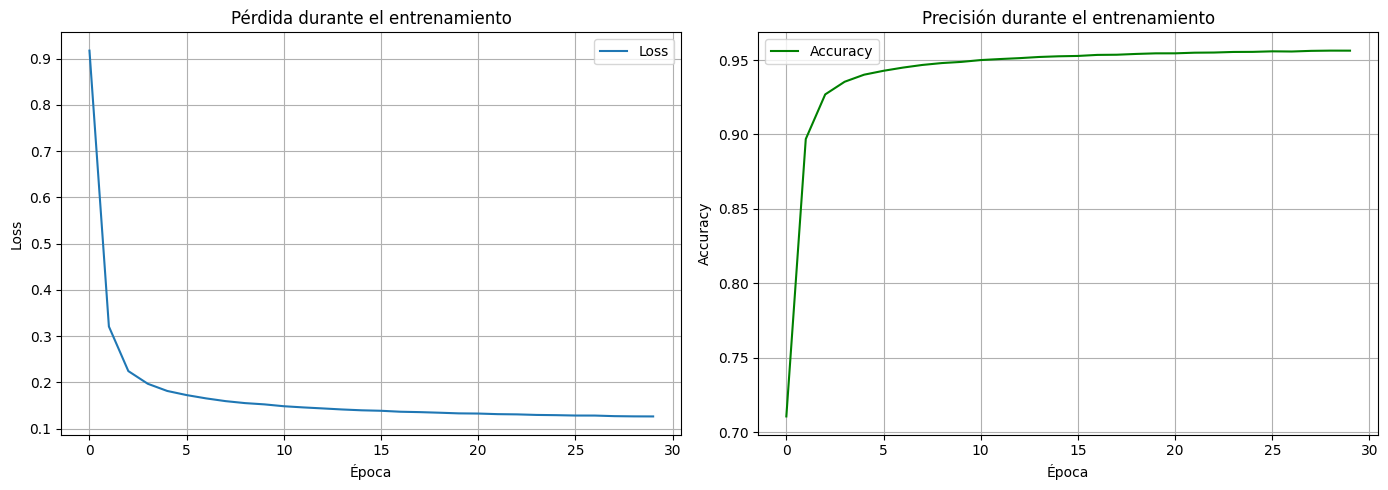

In [8]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Loss')
axes[0].set_title('Pérdida durante el entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)
# Precisión
axes[1].plot(history.history['accuracy'], label='Accuracy', color='green')
axes[1].set_title('Precisión durante el entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [14]:
def remove_accents(text):
    text = text.replace('á', 'a')
    text = text.replace('é', 'e')
    text = text.replace('í', 'i')
    text = text.replace('ó', 'o')
    text = text.replace('ú', 'u')
    text = text.replace('ü', 'u')
    return text

def generar_texto(model, inicio, longitud=100, temperatura=1.0):
  """Genera texto de forma autoregresiva."""
  generado = list(encode(remove_accents(inicio.lower()))) # Convert inicio to lowercase and remove accents
  for _ in range(longitud):
    input_seq = generado[-SEQ_LENGTH:]
    input_seq = np.array(input_seq)[np.newaxis, :]
    if len(input_seq[0]) < SEQ_LENGTH:
      pad_len = SEQ_LENGTH - len(input_seq[0])
      input_seq = np.pad(input_seq, ((0,0), (pad_len, 0)))
    preds = model.predict(input_seq, verbose=0)[0, -1, :]
    preds = np.log(preds + 1e-10) / temperatura
    preds = np.exp(preds) / np.sum(np.exp(preds))
    next_idx = np.random.choice(len(preds), p=preds)
    generado.append(next_idx)
    if idx_to_char[next_idx] == '\n':
      break
  return decode(generado)

# Generar con diferentes temperaturas
print("=== Temperatura 0.5 ===")
print(generar_texto(model, "El gobierno ", temperatura=0.5))
print("\n=== Temperatura 1.0 ===")
print(generar_texto(model, "El gobierno ", temperatura=1.0))
print("\n=== Temperatura 1.5 ===")
print(generar_texto(model, "El gobierno ", temperatura=1.5))

=== Temperatura 0.5 ===
el gobierno estilo ches electricos y ciudades inteligentes


=== Temperatura 1.0 ===
el gobierno esthile en la era de la tecnologia avanzada estudiantes para un mundo digital


=== Temperatura 1.5 ===
el gobierno uciencia como tendencia en augostios precisos de en precision y terapias genicas



In [15]:
inicios = ["La economía ", "Un nuevo ", "El presidente ", "Argentina ", "Se espera "]
for inicio in inicios:
  print(f"Inicio: '{inicio}'")
  print(f"  → {generar_texto(model, inicio, temperatura=0.8)}")

Inicio: 'La economía '
  → la economia y su contribucion aer y su contribucion a ciudades mas verdes y habitables

Inicio: 'Un nuevo '
  → un nuevo chluchos cultncientes para un mundo diaccion y el cambio

Inicio: 'El presidente '
  → el presidente con estilo y responsabilidad hacia los mares y su importancia para la vida en la tierra

Inicio: 'Argentina '
  → argentina emergente nuestra privacidad en linea y la medicina de precision de la ia

Inicio: 'Se espera '
  → se espera el cine entoryciones con el medio ambiente

